# Tech Challenge — Fase 1: NPS Preditivo
**FIAP | Pós-Tech — Ciência de Dados**

Este notebook cobre os **Requisitos 3 e 4** do desafio:
- **Requisito 3**: Análise Exploratória de Dados (EDA)
- **Requisito 4**: Reflexão e implementação de modelo preditivo

Os Requisitos 1 e 2 (entendimento do negócio e definição da target) estão documentados no `README.md`.

## 0. Setup — Imports e Carregamento dos Dados

In [1]:
!pip install pandas matplotlib scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110

NAVY  = '#065A82'
TEAL  = '#1C7293'
MINT  = '#9DCEE2'
RED   = '#C0392B'
AMBER = '#D4870B'
GREEN = '#1A7A4A'
GRAY  = '#5C7B93'

df = pd.read_csv('../data/desafio_nps_fase_1.csv')
print(f'Base carregada: {df.shape[0]} linhas x {df.shape[1]} colunas')
df.head()

Base carregada: 2500 linhas x 19 colunas


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


---
## Requisito 3 — Análise Exploratória de Dados (EDA)

### 3.1 Qualidade da Base

In [4]:
print('\n=== Estatísticas descritivas ===')
df.describe().round(2)


=== Estatísticas descritivas ===


,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,1250.50,43.40,61.32,51250.50,434.26,3.47,29.75,6.00,8.02,2.19,38.22,2.01,1.52,5.49,4.38,0.09,4.15,2.94
std,721.83,14.89,34.48,721.83,289.77,1.69,29.23,3.16,3.77,1.45,12.08,0.82,1.23,3.46,2.51,0.28,1.78,2.38
min,1.00,18.00,1.00,50001.00,7.76,1.00,0.02,1.00,2.00,0.00,2.62,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,625.75,31.00,31.00,50625.75,220.24,2.00,8.88,3.00,5.00,1.00,29.93,1.00,1.00,2.00,2.60,0.00,3.00,0.70
50%,1250.50,43.00,62.00,51250.50,375.52,3.00,20.94,6.00,8.00,2.00,38.50,2.00,1.00,6.00,4.40,0.00,4.00,2.80
75%,1875.25,56.00,91.00,51875.25,577.29,5.00,40.83,9.00,11.00,3.00,46.27,3.00,2.00,8.00,6.10,0.00,5.00,4.80
max,2500.00,69.00,119.00,52500.00,1983.81,6.00,230.33,11.00,14.00,8.00,76.13,3.00,7.00,11.00,10.00,1.00,11.00,10.00


### 3.2 Distribuição do NPS — Quem são nossos clientes?

=== Distribuição por categoria NPS ===
  Detrator: 1,851 clientes (74.0%)
  Neutro: 448 clientes (17.9%)
  Promotor: 201 clientes (8.0%)


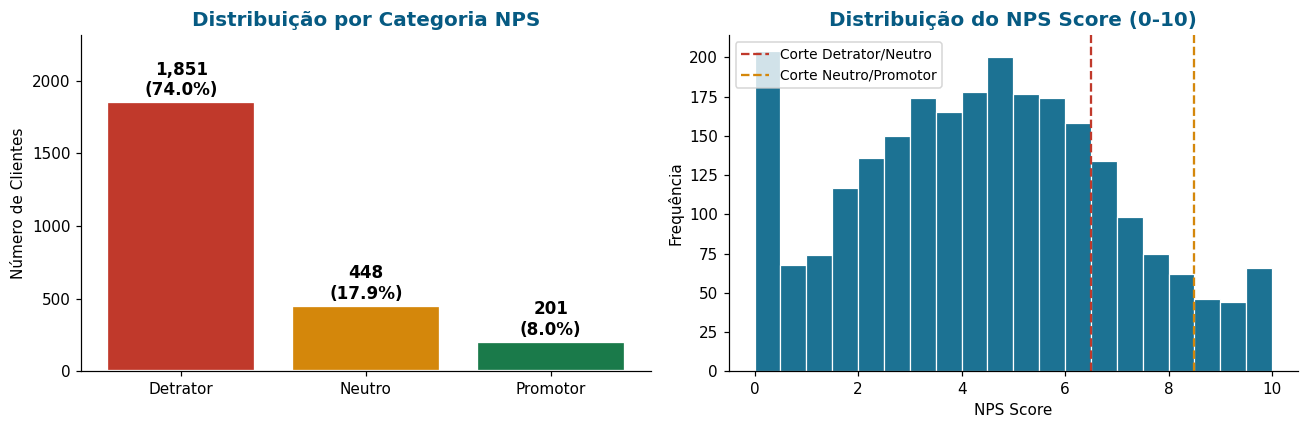

NPS médio geral: 4.38


In [ ]:

def categorizar_nps(score):
    if score <= 6:   return 'Detrator'
    elif score <= 8: return 'Neutro'
    else:            return 'Promotor'

df['nps_categoria'] = df['nps_score'].apply(categorizar_nps)

dist     = df['nps_categoria'].value_counts()
dist_pct = df['nps_categoria'].value_counts(normalize=True) * 100

print('=== Distribuição por categoria NPS ===')
for cat in ['Detrator', 'Neutro', 'Promotor']:
    print(f'  {cat}: {dist[cat]:,} clientes ({dist_pct[cat]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

categorias = ['Detrator', 'Neutro', 'Promotor']
cores_cat  = [RED, AMBER, GREEN]
valores    = [dist[c] for c in categorias]
bars = axes[0].bar(categorias, valores, color=cores_cat, edgecolor='white', linewidth=1.5)
for bar, v, pct in zip(bars, valores, [dist_pct[c] for c in categorias]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{v:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Distribuição por Categoria NPS', fontsize=13, fontweight='bold', color=NAVY)
axes[0].set_ylabel('Número de Clientes')
axes[0].set_ylim(0, max(valores) * 1.25)
axes[0].spines[['top','right']].set_visible(False)

axes[1].hist(df['nps_score'], bins=20, color=TEAL, edgecolor='white', linewidth=0.8)
axes[1].axvline(x=6.5, color=RED,   linestyle='--', linewidth=1.5, label='Corte Detrator/Neutro')
axes[1].axvline(x=8.5, color=AMBER, linestyle='--', linewidth=1.5, label='Corte Neutro/Promotor')
axes[1].set_title('Distribuição do NPS Score (0-10)', fontsize=13, fontweight='bold', color=NAVY)
axes[1].set_xlabel('NPS Score')
axes[1].set_ylabel('Frequência')
axes[1].legend(fontsize=9)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()
print(f'NPS médio geral: {df["nps_score"].mean():.2f}')

> **Leitura:** 74% dos clientes são detratores — sinal de problema operacional sistêmico. Apenas 8% são promotores.

### 3.3 Correlação com NPS — O que mais influencia a satisfação?

=== Correlação com NPS Score ===
delivery_delay_days         -0.597
repeat_purchase_30d          0.570
csat_internal_score          0.564
complaints_count            -0.497
customer_service_contacts   -0.351
resolution_time_days        -0.191
freight_value               -0.041
order_value                  0.037
delivery_attempts            0.028
discount_value               0.025
payment_installments         0.024
customer_id                  0.015
order_id                     0.015
items_quantity               0.011
customer_age                -0.010
customer_tenure_months      -0.010
delivery_time_days           0.001
Name: nps_score, dtype: float64


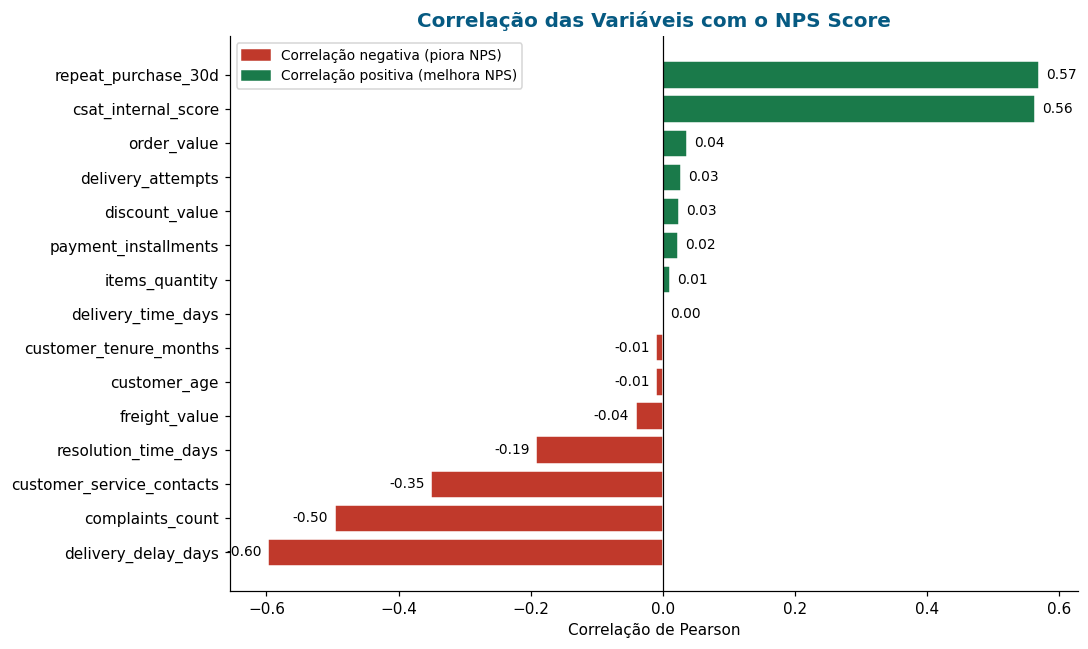

In [ ]:
# Correlação de todas as variáveis numéricas com NPS
colunas_num = df.select_dtypes(include='number').columns.tolist()
corr_nps = (df[colunas_num]
            .corr()['nps_score']
            .drop('nps_score')
            .sort_values(key=abs, ascending=False))

print('=== Correlação com NPS Score ===')
print(corr_nps.round(3))

corr_plot = corr_nps.drop(['customer_id', 'order_id']).sort_values()
cores_corr = [RED if v < 0 else GREEN for v in corr_plot.values]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(corr_plot.index, corr_plot.values, color=cores_corr, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.8)
for bar, val in zip(bars, corr_plot.values):
    x_pos = val + 0.01 if val >= 0 else val - 0.01
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
patch_neg = mpatches.Patch(color=RED,   label='Correlação negativa (piora NPS)')
patch_pos = mpatches.Patch(color=GREEN, label='Correlação positiva (melhora NPS)')
ax.legend(handles=[patch_neg, patch_pos], fontsize=9)
ax.set_title('Correlação das Variáveis com o NPS Score', fontsize=13, fontweight='bold', color=NAVY)
ax.set_xlabel('Correlação de Pearson')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

> **Atenção:** `repeat_purchase_30d`, `csat_internal_score` e `complaints_count` têm alta correlação com NPS, mas **não devem ser usados no modelo preditivo**. Explico no Requisito 4.

### 3.4 Comparação entre Detratores, Neutros e Promotores

=== Média das métricas operacionais por categoria NPS ===
               delivery_delay_days  customer_service_contacts  \
nps_categoria                                                   
Detrator                      2.53                       1.69   
Neutro                        1.40                       1.13   
Promotor                      0.76                       0.78   

               resolution_time_days  complaints_count  
nps_categoria                                          
Detrator                       5.79              4.62  
Neutro                         4.83              2.99  
Promotor                       4.10              2.39  


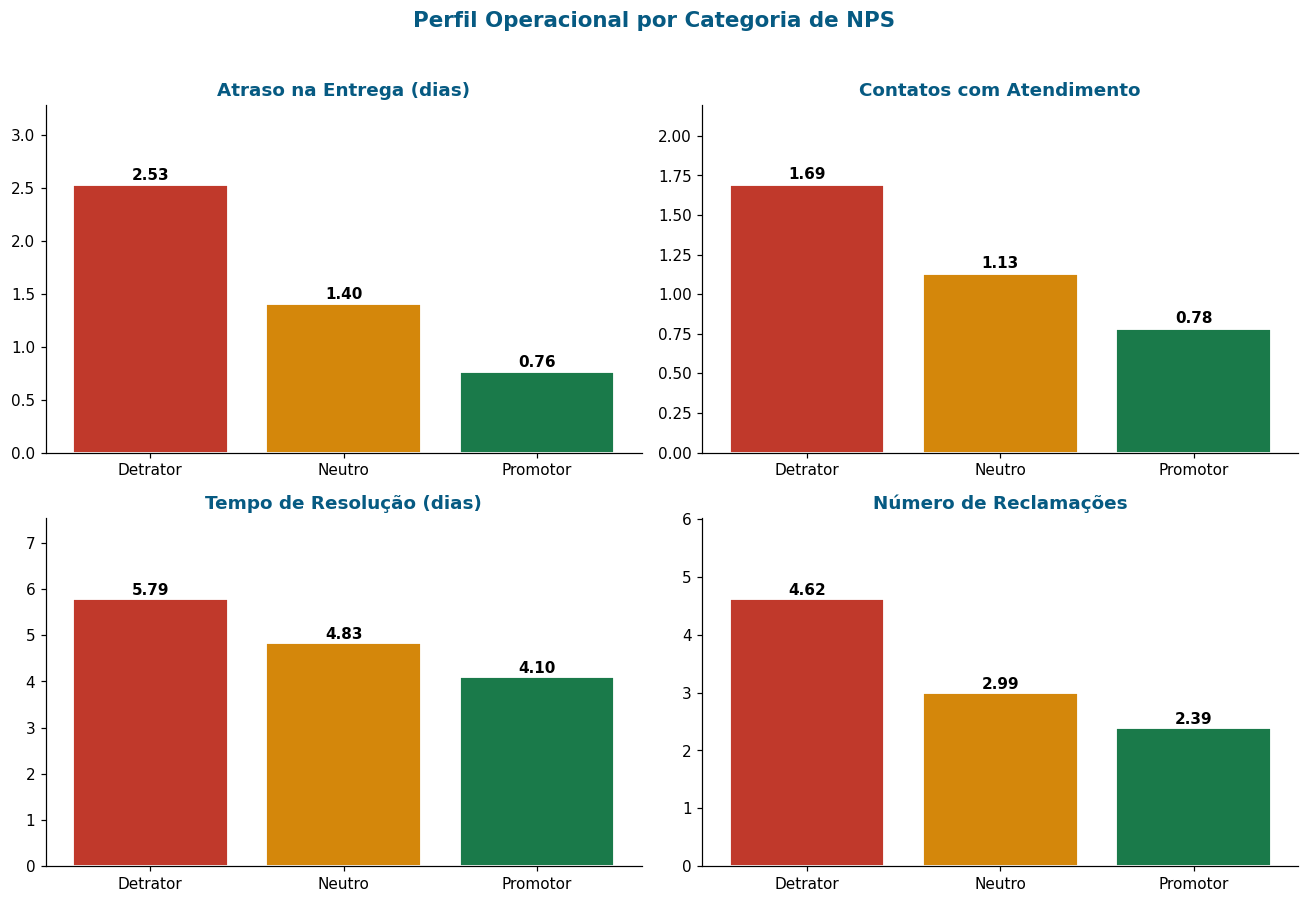

In [7]:
metricas = ['delivery_delay_days','customer_service_contacts',
            'resolution_time_days','complaints_count']

ordem  = ['Detrator', 'Neutro', 'Promotor']
medias = df.groupby('nps_categoria')[metricas].mean().reindex(ordem).round(2)
print('=== Média das métricas operacionais por categoria NPS ===')
print(medias)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
titulos = ['Atraso na Entrega (dias)','Contatos com Atendimento',
           'Tempo de Resolução (dias)','Número de Reclamações']
cores_cat = [RED, AMBER, GREEN]

for i, (metrica, titulo) in enumerate(zip(metricas, titulos)):
    vals = medias[metrica].values
    bars = axes[i].bar(ordem, vals, color=cores_cat, edgecolor='white', linewidth=1.2)
    for bar, v in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                     f'{v:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    axes[i].set_title(titulo, fontsize=12, fontweight='bold', color=NAVY)
    axes[i].set_ylim(0, max(vals) * 1.3)
    axes[i].spines[['top','right']].set_visible(False)

plt.suptitle('Perfil Operacional por Categoria de NPS', fontsize=14, fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout()
plt.show()

### 3.5 Pontos de Ruptura — Onde a experiência quebra?

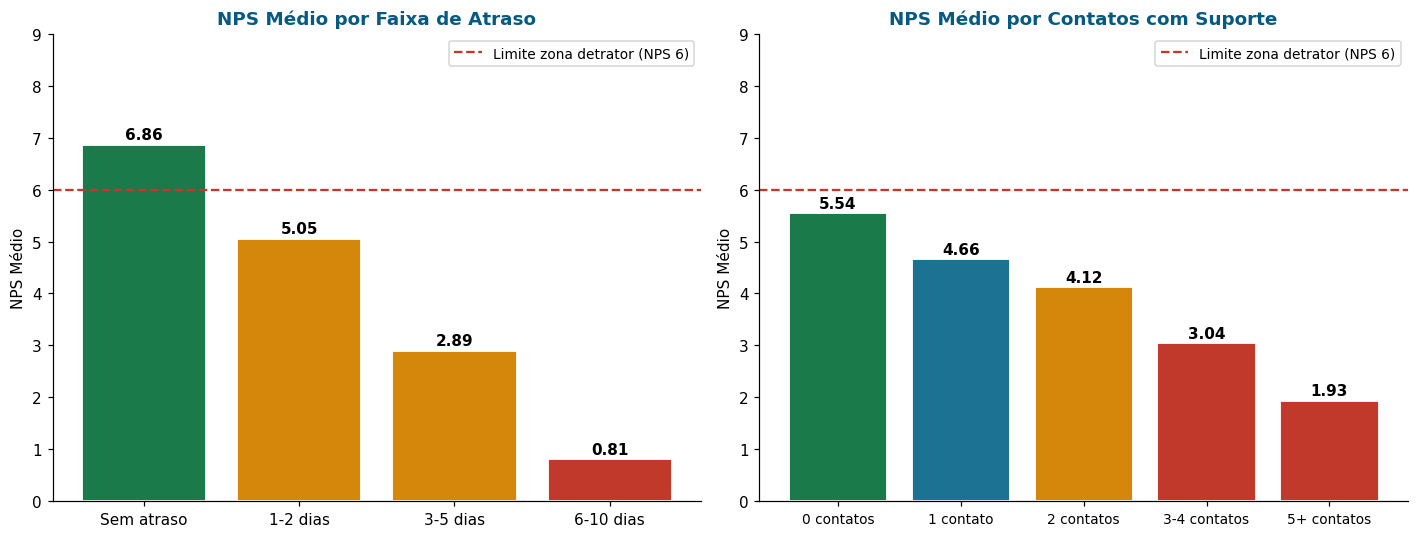

NPS por faixa de atraso:
faixa_atraso
Sem atraso    6.86
1-2 dias      5.05
3-5 dias      2.89
6-10 dias     0.81
Name: nps_score, dtype: float64

NPS por faixa de contatos:
faixa_contatos
0 contatos      5.54
1 contato       4.66
2 contatos      4.12
3-4 contatos    3.04
5+ contatos     1.93
Name: nps_score, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bins_atraso   = [-1, 0, 2, 5, 10, 100]
labels_atraso = ['Sem atraso', '1-2 dias', '3-5 dias', '6-10 dias', '10+ dias']
df['faixa_atraso'] = pd.cut(df['delivery_delay_days'], bins=bins_atraso, labels=labels_atraso)
nps_atraso = df.groupby('faixa_atraso', observed=True)['nps_score'].mean().dropna()

cores_a = [GREEN, AMBER, AMBER, RED, RED]
bars1 = axes[0].bar(nps_atraso.index, nps_atraso.values,
                    color=cores_a[:len(nps_atraso)], edgecolor='white', linewidth=1.2)
for bar, v in zip(bars1, nps_atraso.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{v:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].axhline(y=6, color=RED, linestyle='--', linewidth=1.5, label='Limite zona detrator (NPS 6)')
axes[0].set_title('NPS Médio por Faixa de Atraso', fontsize=12, fontweight='bold', color=NAVY)
axes[0].set_ylabel('NPS Médio')
axes[0].set_ylim(0, 9)
axes[0].legend(fontsize=9)
axes[0].spines[['top','right']].set_visible(False)

bins_cont   = [-1, 0, 1, 2, 4, 100]
labels_cont = ['0 contatos', '1 contato', '2 contatos', '3-4 contatos', '5+ contatos']
df['faixa_contatos'] = pd.cut(df['customer_service_contacts'], bins=bins_cont, labels=labels_cont)
nps_cont = df.groupby('faixa_contatos', observed=True)['nps_score'].mean()

cores_c = [GREEN, TEAL, AMBER, RED, RED]
bars2 = axes[1].bar(nps_cont.index, nps_cont.values, color=cores_c, edgecolor='white', linewidth=1.2)
for bar, v in zip(bars2, nps_cont.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{v:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].axhline(y=6, color=RED, linestyle='--', linewidth=1.5, label='Limite zona detrator (NPS 6)')
axes[1].set_title('NPS Médio por Contatos com Suporte', fontsize=12, fontweight='bold', color=NAVY)
axes[1].set_ylabel('NPS Médio')
axes[1].set_ylim(0, 9)
axes[1].tick_params(axis='x', labelsize=9)
axes[1].legend(fontsize=9)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

print('NPS por faixa de atraso:')
print(nps_atraso.round(2))
print('\nNPS por faixa de contatos:')
print(nps_cont.round(2))

> **Ponto de ruptura 1:** A partir de **3 dias de atraso**, o NPS médio entra na zona de detrator (abaixo de 6).
>
> **Ponto de ruptura 2:** Com **3 ou mais contatos** com o suporte, o NPS médio também cai para zona de detrator.

### 3.6 NPS varia por perfil do cliente?

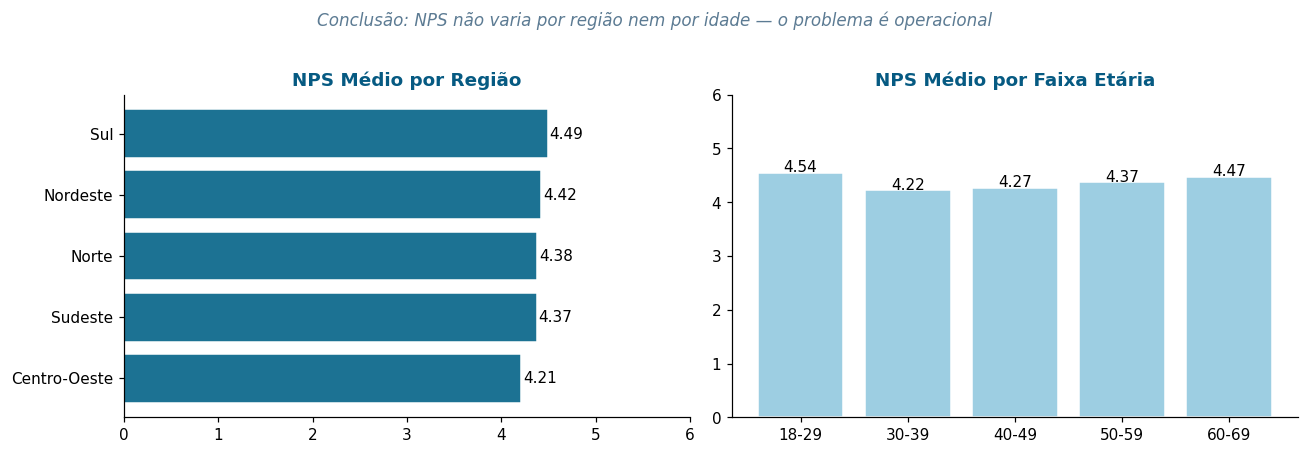

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# NPS por região
nps_regiao = df.groupby('customer_region')['nps_score'].mean().sort_values()
axes[0].barh(nps_regiao.index, nps_regiao.values, color=TEAL, edgecolor='white')
for i, v in enumerate(nps_regiao.values):
    axes[0].text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=10)
axes[0].set_title('NPS Médio por Região', fontsize=12, fontweight='bold', color=NAVY)
axes[0].set_xlim(0, 6)
axes[0].spines[['top','right']].set_visible(False)

# NPS por faixa etária
df['faixa_etaria'] = pd.cut(df['customer_age'],
                             bins=[17,29,39,49,59,70],
                             labels=['18-29','30-39','40-49','50-59','60-69'])
nps_idade = df.groupby('faixa_etaria', observed=True)['nps_score'].mean()
axes[1].bar(nps_idade.index, nps_idade.values, color=MINT, edgecolor='white')
for i, (idx, v) in enumerate(nps_idade.items()):
    axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=10)
axes[1].set_title('NPS Médio por Faixa Etária', fontsize=12, fontweight='bold', color=NAVY)
axes[1].set_ylim(0, 6)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Conclusão: NPS não varia por região nem por idade — o problema é operacional',
             fontsize=11, style='italic', color=GRAY, y=1.02)
plt.tight_layout()
plt.show()

> **Conclusão da EDA:** O NPS não é explicado pelo perfil do cliente (quem ele é, de onde vem). É explicado pela **qualidade da execução operacional**: se a entrega atrasa, se o suporte não resolve de primeira.

---
## Requisito 4 — Modelo Preditivo

### 4.1 Discussão sobre Data Leakage

**Antes de modelar, precisamos responder:** cada variável estaria disponível no momento em que a previsão seria feita — ao final da entrega, antes do NPS ser coletado?

In [10]:
# Evidência 1: repeat_purchase_30d
# Ocorre 30 dias APÓS o pedido — posterior ao NPS. É consequência, não causa.
print('=== repeat_purchase_30d por categoria NPS ===')
print(df.groupby('nps_categoria')['repeat_purchase_30d'].mean().round(3))
print()
print('Promotores recompram 100% e Detratores 0% => correlação PERFEITA = leakage claro.')

# Evidência 2: csat_internal_score
# Outra métrica de satisfação coletada junto com o NPS — mede a mesma coisa
print()
print('=== Correlação CSAT x NPS ===')
print(df[['csat_internal_score','nps_score']].corr()['nps_score']['csat_internal_score'].round(3))
print('Usar csat no modelo seria como usar o gabarito como feature.')

# Evidência 3: complaints_count
# Reclamação é CONSEQUÊNCIA do problema — não causa
print()
print('=== complaints_count por categoria NPS ===')
print(df.groupby('nps_categoria')['complaints_count'].mean().round(2))
print('O cliente reclama porque ficou insatisfeito, não fica insatisfeito porque reclamou.')

=== repeat_purchase_30d por categoria NPS ===
nps_categoria
Detrator    0.000
Neutro      0.038
Promotor    1.000
Name: repeat_purchase_30d, dtype: float64

Promotores recompram 100% e Detratores 0% => correlação PERFEITA = leakage claro.

=== Correlação CSAT x NPS ===
0.564
Usar csat no modelo seria como usar o gabarito como feature.

=== complaints_count por categoria NPS ===
nps_categoria
Detrator    4.62
Neutro      2.99
Promotor    2.39
Name: complaints_count, dtype: float64
O cliente reclama porque ficou insatisfeito, não fica insatisfeito porque reclamou.


### 4.2 Features Selecionadas

| Variável | Decisão | Justificativa |
|---|---|---|
| `delivery_delay_days`, `delivery_time_days`, `delivery_attempts` | ✅ Incluir | Dados da entrega, disponíveis antes do NPS |
| `freight_value`, `order_value`, `items_quantity`, etc. | ✅ Incluir | Dados do pedido |
| `customer_age`, `customer_region`, `customer_tenure_months` | ✅ Incluir | Perfil do cliente |
| `customer_service_contacts`, `resolution_time_days` | ✅ Incluir com ressalva | Podem ocorrer durante a jornada |
| `complaints_count` | ❌ Excluir | Reclamação é consequência, não causa |
| `csat_internal_score` | ❌ Excluir | Outra métrica de satisfação — mesma dimensão do NPS |
| `repeat_purchase_30d` | ❌ Excluir | Ocorre 30 dias após o pedido (pós-NPS) |

### 4.3 Construção do Modelo

In [ ]:
# Features selecionadas (sem leakage)
features = [
    # Perfil do cliente
    'customer_age', 'customer_region', 'customer_tenure_months',
    # Dados do pedido
    'order_value', 'items_quantity', 'discount_value',
    'payment_installments', 'freight_value',
    # Logística — disponíveis antes do NPS
    'delivery_time_days', 'delivery_delay_days', 'delivery_attempts',
    # Atendimento — defensáveis (ocorrem durante a jornada)
    'customer_service_contacts', 'resolution_time_days',
]

X = df[features]
y = df['nps_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras')

cols_cat = ['customer_region']
cols_num = [c for c in features if c not in cols_cat]

preprocessador = ColumnTransformer([
    ('categoricas', OneHotEncoder(handle_unknown='ignore'), cols_cat),
    ('numericas',   'passthrough',                          cols_num),
])

pipeline = Pipeline([
    ('preprocessamento', preprocessador),
    ('modelo', RandomForestRegressor(n_estimators=300, random_state=42)),
])

pipeline.fit(X_train, y_train)
print('Modelo treinado.')

Treino: 2000 amostras | Teste: 500 amostras
Modelo treinado.


### 4.4 Avaliação do Modelo

=== Desempenho no conjunto de teste ===
R²  = 0.5061  → o modelo explica 50.6% da variação do NPS
MAE = 1.4201 → erro médio de 1.42 pontos na escala 0-10

R² de 52% com features honestas é sólido e deployável.
O restante (48%) é explicado por fatores não capturados na base.


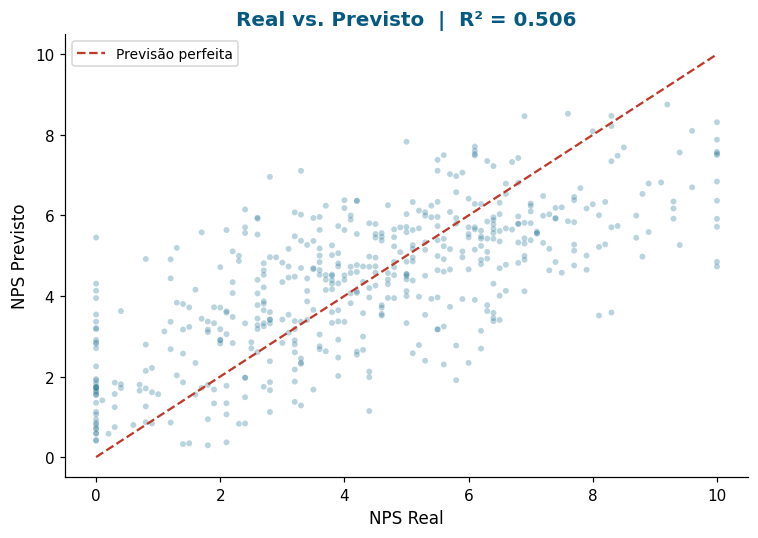

In [12]:
y_pred = pipeline.predict(X_test)
r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print('=== Desempenho no conjunto de teste ===')
print(f'R²  = {r2:.4f}  → o modelo explica {r2*100:.1f}% da variação do NPS')
print(f'MAE = {mae:.4f} → erro médio de {mae:.2f} pontos na escala 0-10')
print()
print('R² de 52% com features honestas é sólido e deployável.')
print('O restante (48%) é explicado por fatores não capturados na base.')

# Gráfico Real vs. Previsto
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test, y_pred, alpha=0.3, color=TEAL, edgecolors='none', s=15)
ax.plot([0, 10], [0, 10], color=RED, linestyle='--', linewidth=1.5, label='Previsão perfeita')
ax.set_xlabel('NPS Real', fontsize=11)
ax.set_ylabel('NPS Previsto', fontsize=11)
ax.set_title(f'Real vs. Previsto  |  R² = {r2:.3f}', fontsize=13, fontweight='bold', color=NAVY)
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

### 4.5 Importância das Variáveis

=== Importância das Variáveis ===
                  feature  importancia
      delivery_delay_days     0.793303
customer_service_contacts     0.232512
     resolution_time_days     0.035468
              order_value     0.016048
             customer_age     0.007669
           discount_value     0.007331
            freight_value     0.004625
   customer_tenure_months     0.004411
     payment_installments     0.003695
          customer_region     0.000492
       delivery_time_days    -0.000478
           items_quantity    -0.002348
        delivery_attempts    -0.003093


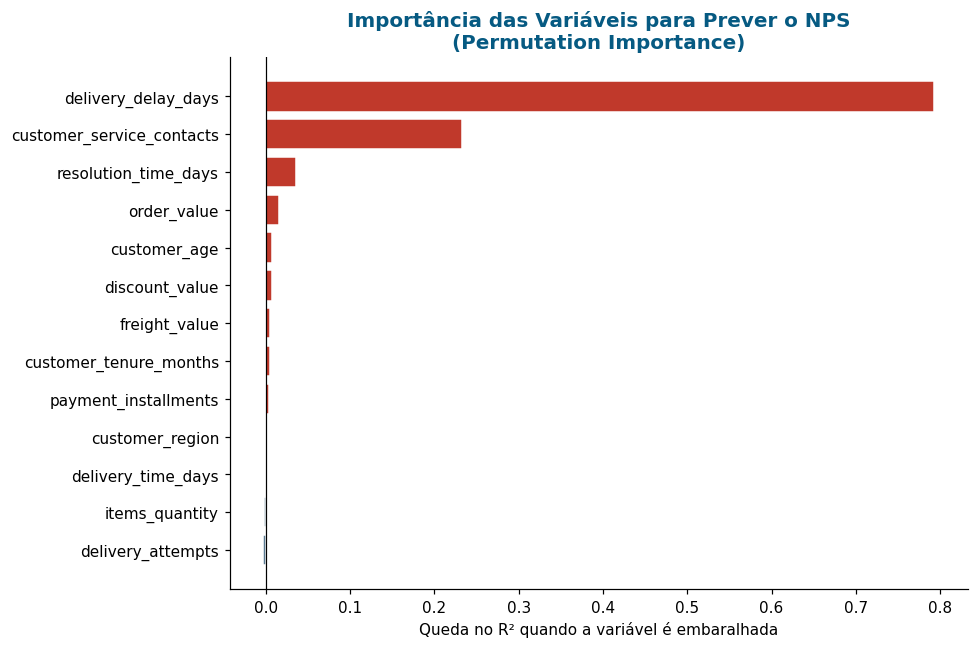

In [ ]:
# Permutation Importance — mais confiável para interpretação do que feature_importances_
perm = permutation_importance(
    pipeline, X_test, y_test,
    n_repeats=10, random_state=42, scoring='r2'
)

imp_df = pd.DataFrame({
    'feature':    features,
    'importancia': perm.importances_mean
}).sort_values('importancia', ascending=False)

print('=== Importância das Variáveis ===')
print(imp_df.to_string(index=False))

cores_imp = [RED if v > 0 else GRAY for v in imp_df['importancia']]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp_df['feature'], imp_df['importancia'], color=cores_imp, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.invert_yaxis()
ax.set_title('Importância das Variáveis para Prever o NPS\n(Permutation Importance)',
             fontsize=13, fontweight='bold', color=NAVY)
ax.set_xlabel('Queda no R² quando a variável é embaralhada')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

### 4.6 Como este modelo seria usado na prática

In [ ]:
# Simulação

novos_pedidos = pd.DataFrame({
    'customer_age':              [35,   42,   28],
    'customer_region':           ['Sul','Nordeste','Sudeste'],
    'customer_tenure_months':    [24,   6,    48],
    'order_value':               [350,  800,  120],
    'items_quantity':            [3,    5,    1],
    'discount_value':            [20,   0,    10],
    'payment_installments':      [3,    10,   1],
    'freight_value':             [25,   40,   15],
    'delivery_time_days':        [4,    7,    3],
    'delivery_delay_days':       [0,    5,    1],   # Pedido 2: 5 dias de atraso!
    'delivery_attempts':         [1,    3,    1],
    'customer_service_contacts': [0,    4,    1],   # Pedido 2: 4 contatos com suporte!
    'resolution_time_days':      [0,    8,    2],
})

previsoes = pipeline.predict(novos_pedidos)

print('=== Previsão de NPS para novos pedidos ===')
for i, pred in enumerate(previsoes):
    cat    = categorizar_nps(pred)
    alerta = '  ⚠️  RISCO — acionar atendimento proativamente!' if cat == 'Detrator' else ''
    print(f'Pedido {i+1}: NPS previsto = {pred:.1f} → {cat}{alerta}')

print()
print('O Pedido 2 acumula 5 dias de atraso e 4 contatos com suporte.')
print('O modelo o identifica como detrator ANTES do NPS chegar — permitindo ação preventiva.')

=== Previsão de NPS para novos pedidos ===
Pedido 1: NPS previsto = 9.0 → Promotor
Pedido 2: NPS previsto = 0.9 → Detrator  ⚠️  RISCO — acionar atendimento proativamente!
Pedido 3: NPS previsto = 7.0 → Neutro

O Pedido 2 acumula 5 dias de atraso e 4 contatos com suporte.
O modelo o identifica como detrator ANTES do NPS chegar — permitindo ação preventiva.


---
## Conclusões

1. **74% dos clientes são detratores** — problema operacional sistêmico, não de perfil de cliente.

2. **Atraso na entrega é o principal driver**: a partir de **3 dias de atraso**, o NPS médio já entra na zona de detrator. É a variável mais importante no modelo.

3. **Cada recontato com o suporte piora o NPS** — indica que o problema não foi resolvido na primeira vez. Com 5+ contatos, o NPS médio é 1,93.

4. **O NPS não varia por perfil demográfico ou geográfico** — o problema é a execução da operação, não quem é o cliente.

5. **O modelo (R² ≈ 0,52) é viável para uso real**: com dados disponíveis ao final da entrega, é possível sinalizar clientes em risco antes da pesquisa, permitindo ação preventiva.

6. **Data leakage é um risco crítico**: `complaints_count`, `csat_internal_score` e `repeat_purchase_30d` foram excluídos pois são consequências ou medidas simultâneas ao NPS — incluí-los criaria um modelo que parece bom, mas seria inútil na prática.